Bismillah 
Rabi Zidni Ilma

In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset to inspect columns and data
df = pd.read_csv('student_habits_performance.csv')
print("Columns:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nFirst 3 rows:\n", df.head(3))
print("\nData Info:\n")
df.info()

Columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Shape: (1000, 16)

First 3 rows:
   student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0     

In [3]:
# Let's inspect missing values, dtypes, and see which numeric features exist
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns:", numeric_cols)

# Check missing values
print("\nMissing values:\n", df.isnull().sum())


Numeric columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Missing values:
 student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [4]:
# Let's run Linear Regression using numeric columns as specified in prompt ("Baaki numeric columns ko features ke taur par use karein.")
# Target: exam_score
# Features: numeric columns excluding student_id and exam_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [c for c in numeric_cols if c != 'exam_score']
X = df[features]
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 4.1302
MSE: 25.9210
RMSE: 5.0913
R2 Score: 0.8989


In [5]:
# Let's check feature coefficients to give clear insights
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)
print(f"Intercept: {model.intercept_:.4f}")

                 Feature  Coefficient
1    study_hours_per_day     9.533589
5            sleep_hours     1.989896
7   mental_health_rating     1.952032
6     exercise_frequency     1.315593
4  attendance_percentage     0.145895
0                    age     0.052559
3          netflix_hours    -2.316592
2     social_media_hours    -2.701878
Intercept: 5.9063


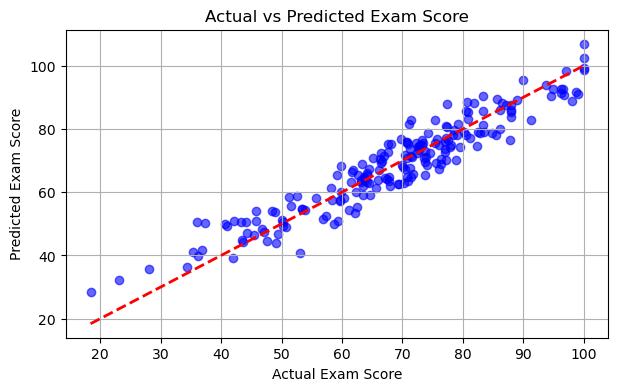

In [7]:
# Actual vs Predicted Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Score')
plt.grid(True)
plt.show()